## 编程练习2：用两层ReLU网络拟合函数

**目标**：自定义一个函数，使用基于ReLU激活函数的两层神经网络来拟合它。

**选定函数**：
$$f(x) = \sin(2\pi x) + 0.5\cos(4\pi x)$$

这个函数是正弦波和余弦波的叠加，形状复杂，适合测试神经网络的拟合能力。

## 1. 导入必要的库

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

# 设置随机种子，保证结果可复现
np.random.seed(42)
torch.manual_seed(42)

print('PyTorch 版本:', torch.__version__)

PyTorch 版本: 2.0.1+cu117


## 2. 定义目标函数 & 采样数据

In [2]:
# ========== 2.1 定义目标函数 ==========
def target_function(x):
    """
    目标函数：sin(2πx) + 0.5*cos(4πx)
    输入：x，形状为 (N,)
    输出：y，形状为 (N,)
    """
    return np.sin(2 * np.pi * x) + 0.5 * np.cos(4 * np.pi * x)


# ========== 2.2 在函数上采样，生成训练集和测试集 ==========
# x 的范围：[-1, 1]
x_min, x_max = -1.0, 1.0

# 训练集：随机采样 800 个点，并加入少量噪声（模拟真实数据）
n_train = 800
x_train = np.random.uniform(x_min, x_max, n_train)      # 随机均匀采样
noise = np.random.normal(0, 0.05, n_train)               # 均值0、标准差0.05的高斯噪声
y_train = target_function(x_train) + noise               # 加入噪声

# 测试集：均匀采样 200 个点（不加噪声，用于评估拟合效果）
n_test = 200
x_test = np.linspace(x_min, x_max, n_test)              # 均匀间隔采样
y_test = target_function(x_test)                         # 真实值，无噪声

# 用于绘图的真实曲线（细密采样）
x_true = np.linspace(x_min, x_max, 1000)
y_true = target_function(x_true)

print(f'训练集大小: {n_train} 个点')
print(f'测试集大小: {n_test} 个点')

训练集大小: 800 个点
测试集大小: 200 个点


C:\Users\User\AppData\Local\Temp\ipykernel_39112\442746843.py:13: UserWarning: Glyph 30446 (\N{CJK UNIFIED IDEOGRAPH-76EE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_39112\442746843.py:13: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_39112\442746843.py:13: UserWarning: Glyph 20989 (\N{CJK UNIFIED IDEOGRAPH-51FD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_39112\442746843.py:13: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_39112\442746843.py:13: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_39112\442746843.py:13: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH

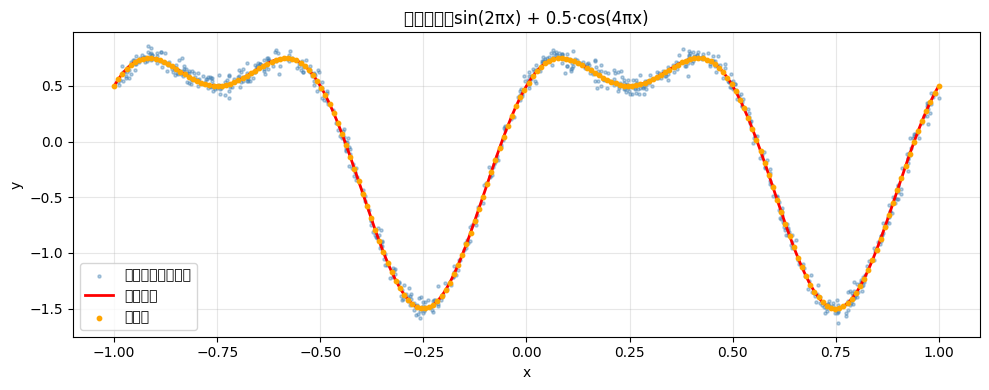

数据可视化完成！


In [3]:
# ========== 2.3 可视化数据 ==========
plt.figure(figsize=(10, 4))

plt.scatter(x_train, y_train, s=5, alpha=0.4, color='steelblue', label='训练集（含噪声）')
plt.plot(x_true, y_true, color='red', linewidth=2, label='真实函数')
plt.scatter(x_test, y_test, s=10, color='orange', label='测试集', zorder=3)

plt.title('目标函数：sin(2πx) + 0.5·cos(4πx)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('data_visualization.png', dpi=150)
plt.show()
print('数据可视化完成！')

## 3. 构建两层ReLU神经网络模型

In [4]:
class TwoLayerReLUNet(nn.Module):
    """
    两层ReLU全连接神经网络
    
    网络结构：
        输入层(1) → 隐藏层(hidden_size) [ReLU] → 输出层(1)
    
    理论依据：
        Cybenko(1989)、Hornik(1989)等研究证明，两层前馈网络
        可以逼近任意连续函数（通用近似定理）。
        Nair & Hinton(2010) 证明 ReLU 同样满足通用近似。
    """
    def __init__(self, hidden_size=128):
        super(TwoLayerReLUNet, self).__init__()
        
        # 第一层：输入维度1 → 隐藏层维度 hidden_size
        self.layer1 = nn.Linear(1, hidden_size)
        
        # 激活函数：ReLU（整流线性单元），f(x) = max(0, x)
        self.relu = nn.ReLU()
        
        # 第二层：隐藏层维度 hidden_size → 输出维度1
        self.layer2 = nn.Linear(hidden_size, 1)
    
    def forward(self, x):
        """
        前向传播
        x: shape (batch_size, 1)
        """
        h = self.relu(self.layer1(x))   # 隐藏层 + ReLU激活
        out = self.layer2(h)             # 输出层（回归任务，无激活函数）
        return out


# 实例化模型，隐藏层128个神经元
model = TwoLayerReLUNet(hidden_size=128)

# 打印模型结构
print('模型结构：')
print(model)

# 统计参数数量
total_params = sum(p.numel() for p in model.parameters())
print(f'\n总参数量：{total_params} 个')

模型结构：
TwoLayerReLUNet(
  (layer1): Linear(in_features=1, out_features=128, bias=True)
  (relu): ReLU()
  (layer2): Linear(in_features=128, out_features=1, bias=True)
)

总参数量：385 个


## 4. 训练模型

In [5]:
# ========== 4.1 数据转换为 PyTorch Tensor ==========
# reshape(-1, 1) 把一维数组变成列向量，形状变为 (N, 1)
X_train = torch.FloatTensor(x_train.reshape(-1, 1))
Y_train = torch.FloatTensor(y_train.reshape(-1, 1))
X_test  = torch.FloatTensor(x_test.reshape(-1, 1))
Y_test  = torch.FloatTensor(y_test.reshape(-1, 1))


# ========== 4.2 定义损失函数和优化器 ==========
# MSE（均方误差）：回归任务常用的损失函数，loss = mean((y_pred - y_true)^2)
criterion = nn.MSELoss()

# Adam 优化器：自适应学习率，比普通梯度下降效果更好
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 学习率调度器：每 500 轮将学习率乘以 0.5，防止后期震荡
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=500, gamma=0.5)


# ========== 4.3 训练循环 ==========
num_epochs = 2000    # 训练总轮数
train_losses = []    # 记录每轮训练损失
test_losses  = []    # 记录每轮测试损失

for epoch in range(num_epochs):
    # --- 训练阶段 ---
    model.train()                          # 切换到训练模式
    optimizer.zero_grad()                  # 清空上一步的梯度
    y_pred = model(X_train)                # 前向传播，得到预测值
    loss = criterion(y_pred, Y_train)      # 计算训练损失
    loss.backward()                        # 反向传播，自动计算梯度
    optimizer.step()                       # 更新参数
    scheduler.step()                       # 更新学习率
    
    # --- 测试阶段（不计算梯度，节省内存）---
    model.eval()
    with torch.no_grad():
        y_test_pred = model(X_test)
        test_loss = criterion(y_test_pred, Y_test)
    
    # 记录损失
    train_losses.append(loss.item())
    test_losses.append(test_loss.item())
    
    # 每 200 轮打印一次进度
    if (epoch + 1) % 200 == 0:
        print(f'Epoch [{epoch+1:4d}/{num_epochs}]  '
              f'训练Loss: {loss.item():.6f}  '
              f'测试Loss: {test_loss.item():.6f}')

print('\n训练完成！')

Epoch [ 200/2000]  训练Loss: 0.352993  测试Loss: 0.358020
Epoch [ 400/2000]  训练Loss: 0.222604  测试Loss: 0.232656
Epoch [ 600/2000]  训练Loss: 0.171421  测试Loss: 0.180714
Epoch [ 800/2000]  训练Loss: 0.141695  测试Loss: 0.149224
Epoch [1000/2000]  训练Loss: 0.113297  测试Loss: 0.119023
Epoch [1200/2000]  训练Loss: 0.100338  测试Loss: 0.105287
Epoch [1400/2000]  训练Loss: 0.088386  测试Loss: 0.092534
Epoch [1600/2000]  训练Loss: 0.079957  测试Loss: 0.083537
Epoch [1800/2000]  训练Loss: 0.074561  测试Loss: 0.077744
Epoch [2000/2000]  训练Loss: 0.069305  测试Loss: 0.072093

训练完成！


## 5. 可视化结果

C:\Users\User\AppData\Local\Temp\ipykernel_39112\1146062611.py:11: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_39112\1146062611.py:11: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_39112\1146062611.py:11: UserWarning: Glyph 36807 (\N{CJK UNIFIED IDEOGRAPH-8FC7}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_39112\1146062611.py:11: UserWarning: Glyph 31243 (\N{CJK UNIFIED IDEOGRAPH-7A0B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_39112\1146062611.py:11: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_39112\1146062611.py:11: UserWarning: Glyph 25439 (\N{CJK UNIFIED IDE

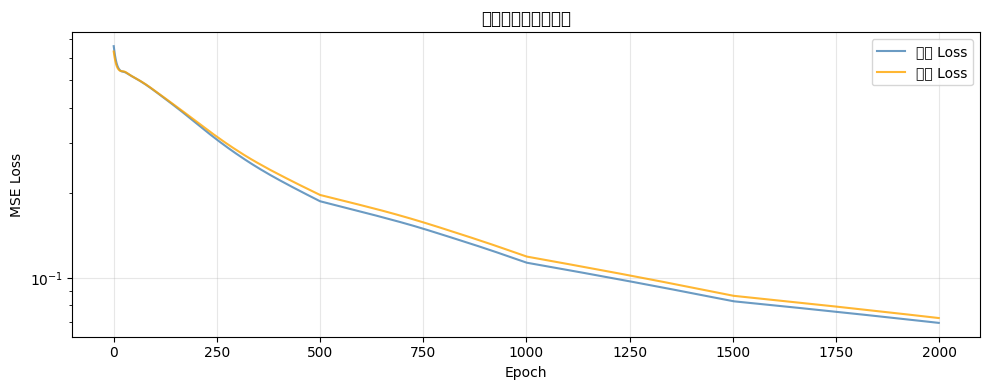

最终训练 MSE: 0.069305
最终测试  MSE: 0.072093


In [6]:
# ========== 5.1 绘制损失曲线 ==========
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='训练 Loss', color='steelblue', alpha=0.8)
plt.plot(test_losses,  label='测试 Loss',  color='orange',    alpha=0.8)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('训练过程：损失曲线')
plt.legend()
plt.yscale('log')   # 对数坐标，更清晰地看到收敛过程
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('loss_curve.png', dpi=150)
plt.show()

print(f'最终训练 MSE: {train_losses[-1]:.6f}')
print(f'最终测试  MSE: {test_losses[-1]:.6f}')

C:\Users\User\AppData\Local\Temp\ipykernel_39112\2825696474.py:25: UserWarning: Glyph 20004 (\N{CJK UNIFIED IDEOGRAPH-4E24}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_39112\2825696474.py:25: UserWarning: Glyph 23618 (\N{CJK UNIFIED IDEOGRAPH-5C42}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_39112\2825696474.py:25: UserWarning: Glyph 32593 (\N{CJK UNIFIED IDEOGRAPH-7F51}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_39112\2825696474.py:25: UserWarning: Glyph 32476 (\N{CJK UNIFIED IDEOGRAPH-7EDC}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_39112\2825696474.py:25: UserWarning: Glyph 23545 (\N{CJK UNIFIED IDEOGRAPH-5BF9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_39112\2825696474.py:25: UserWarning: Glyph 20989 (\N{CJK 

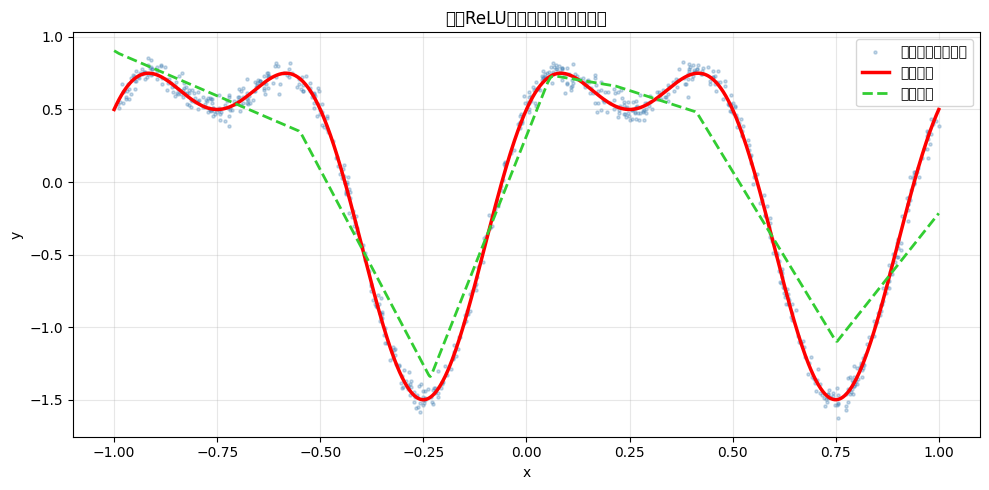

测试集 R² 分数：0.8843  （越接近1.0越好）


In [7]:
# ========== 5.2 绘制拟合效果图 ==========
model.eval()
with torch.no_grad():
    # 在整个区间密集预测，画出拟合曲线
    X_plot = torch.FloatTensor(x_true.reshape(-1, 1))
    y_pred_plot = model(X_plot).numpy().flatten()

plt.figure(figsize=(10, 5))

# 训练集散点
plt.scatter(x_train, y_train, s=5, alpha=0.3, color='steelblue', label='训练集（含噪声）')

# 真实函数
plt.plot(x_true, y_true, color='red', linewidth=2.5, label='真实函数', zorder=3)

# 网络拟合结果
plt.plot(x_true, y_pred_plot, color='limegreen', linewidth=2, 
         linestyle='--', label='网络预测', zorder=4)

plt.title('两层ReLU网络对函数的拟合效果')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fitting_result.png', dpi=150)
plt.show()

# 计算 R² 分数（越接近1说明拟合越好）
ss_res = np.sum((y_test - model(X_test).detach().numpy().flatten())**2)
ss_tot = np.sum((y_test - np.mean(y_test))**2)
r2 = 1 - ss_res / ss_tot
print(f'测试集 R² 分数：{r2:.4f}  （越接近1.0越好）')